In [9]:
pip install pandas seaborn sklearn -q

Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.functions import col, when
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator, RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [11]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dự đoán khả năng đơn hàng bị giao trễ hạn

## Khởi tạo SparkSession

In [12]:
spark = SparkSession.builder \
    .appName("olist_classification") \
    .getOrCreate()

## Load data từ Hadoop

In [13]:
hdfs_path = "hdfs://localhost:9000/bigdata/"

orders = spark.read.csv(hdfs_path + "olist_orders_dataset.csv", header=True, inferSchema=True)
order_items = spark.read.csv(hdfs_path + "olist_order_items_dataset.csv", header=True, inferSchema=True)
products = spark.read.csv(hdfs_path + "olist_products_dataset.csv", header=True, inferSchema=True)
customers = spark.read.csv(hdfs_path + "olist_customers_dataset.csv", header=True, inferSchema=True)

## Tạo biến mục tiêu

In [14]:
orders_delivered = (
    orders
    .filter(col("order_status") == "delivered")
    .filter(col("order_delivered_customer_date").isNotNull())
    .filter(col("order_estimated_delivery_date").isNotNull())
)

orders_delivered = orders_delivered.withColumn(
    "label",
    when(
        col("order_delivered_customer_date")
        >
        col("order_estimated_delivery_date"),
        1
    ).otherwise(0)
)

## Aggregate Order Items & Product Features

In [15]:
items_agg = (
    order_items
    .groupBy("order_id")
    .agg(
        count("*").alias("num_items"),
        sum("price").alias("total_price"),
        sum("freight_value").alias("total_freight")
    )
)

products_agg = (
    order_items
    .join(products, "product_id")
    .groupBy("order_id")
    .agg(
        avg("product_weight_g").alias("avg_weight"),
        avg("product_length_cm").alias("avg_length"),
        avg("product_height_cm").alias("avg_height"),
        avg("product_width_cm").alias("avg_width")
    )
)

In [16]:
df = (
    orders_delivered
    .join(customers, "customer_id")
    .join(items_agg, "order_id")
    .join(products_agg, "order_id")
)

## Feture Engineering

In [17]:
df = (
    df
    .withColumn(
        "estimated_days",
        datediff(
            col("order_estimated_delivery_date"),
            col("order_purchase_timestamp")
        )
    )
    .withColumn(
        "processing_days",
        datediff(
            col("order_delivered_carrier_date"),
            col("order_purchase_timestamp")
        )
    )
    .withColumn(
        "actual_shipping_days",
        datediff(
            col("order_delivered_customer_date"),
            col("order_delivered_carrier_date")
        )
    )
    .withColumn(
        "purchase_month",
        month("order_purchase_timestamp")
    )
    .withColumn(
        "purchase_weekday",
        dayofweek("order_purchase_timestamp")
    )
    .withColumn(
        "freight_ratio",
        col("total_freight") /
        (col("total_price") + lit(0.01))
    )
    .withColumn(
        "product_volume",
        col("avg_length")
        * col("avg_height")
        * col("avg_width")
    )
)

## Tiền xử lý dữ liệu

In [18]:
df = df.na.fill(0)

In [19]:
categorical_cols = [
    "customer_state"
]

numeric_cols = [
    "num_items",
    "total_price",
    "total_freight",
    "avg_weight",
    "product_volume",
    "estimated_days",
    "processing_days",
    "actual_shipping_days",
    "purchase_month",
    "purchase_weekday",
    "freight_ratio"
]

In [20]:
label_counts = (
    df.groupBy("label")
      .count()
      .collect()
)

count_0 = [x["count"] for x in label_counts if x["label"] == 0][0]
count_1 = [x["count"] for x in label_counts if x["label"] == 1][0]

total = count_0 + count_1

weight_0 = total / (2.0 * count_0)
weight_1 = total / (2.0 * count_1)

df = df.withColumn(
    "classWeight",
    when(col("label") == 1, weight_1)
    .otherwise(weight_0)
)

In [21]:
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_vec"
    )
    for c in categorical_cols
]

In [22]:
feature_cols = (
    [f"{c}_vec" for c in categorical_cols]
    + numeric_cols
)

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

## Chia tập Train/Test

In [23]:
train_df, test_df = df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [24]:
# Cache dữ liệu để tránh Spark recompute nhiều lần
train_df.cache()
test_df.cache()

# Materialize cache
train_df.count()
test_df.count()

19308

In [25]:
gbt = GBTClassifier(
    labelCol="label",
    featuresCol="features",
    weightCol="classWeight",
    maxIter=50,
    maxDepth=6,
    stepSize=0.1,
    seed=42
)

## Train mô hình

In [26]:
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [27]:
configs = [
    (4, 20),
    (5, 20),
    (6, 20),
    (5, 30)
]

In [28]:
for depth, iters in configs:

    gbt = GBTClassifier(
        labelCol="label",
        featuresCol="features",
        maxDepth=depth,
        maxIter=iters,
        weightCol="classWeight"
    )

    pipeline = Pipeline(
        stages=indexers + encoders + [assembler, gbt]
    )

    model = pipeline.fit(train_df)

    pred = model.transform(test_df)

    auc = auc_evaluator.evaluate(pred)

    print(depth, iters, auc)

4 20 0.9945885504729699
5 20 0.9969007405862998
6 20 0.9979149054060229
5 30 0.9976847395809532


In [29]:
predictions = model.transform(test_df)

## Đánh giá mô hình

In [30]:


roc_auc = auc_evaluator.evaluate(predictions)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9976847395809532


In [31]:
pr_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderPR"
)

pr_auc = pr_evaluator.evaluate(predictions)

print("PR-AUC:", pr_auc)

PR-AUC: 0.976255800747898


In [32]:
accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    metricName="accuracy"
).evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9694945100476486


In [33]:
f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    metricName="f1"
).evaluate(predictions)

print("F1:", f1)

F1: 0.9715549590004606


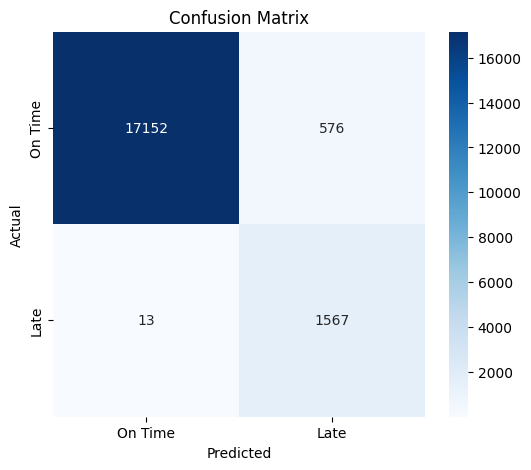

In [34]:
pred_pd = predictions.select(
    "label",
    "prediction"
).toPandas()

cm = confusion_matrix(
    pred_pd["label"],
    pred_pd["prediction"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On Time","Late"],
    yticklabels=["On Time","Late"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()